In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

In [4]:
class FoGModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)
        self.drop = nn.Dropout(0.3)

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)   # (B, 3, 192)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.drop(x)

        x = x.permute(0, 2, 1)   # (B, T, C)

        x, _ = self.lstm(x)
        x = x.mean(dim=1)

        return self.fc(x)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FoGModel().to(device)
model.load_state_dict(torch.load("dl_fog_model_best.pth", map_location=device))
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [6]:
FS = 128
WINDOW_SIZE = 192
STEP = 128

In [7]:
def create_windows(df):
    signals = df[["AccV","AccML","AccAP"]].values

    windows = []
    t_start = []
    t_end = []

    for start in range(0, len(df) - WINDOW_SIZE, STEP):
        end = start + WINDOW_SIZE

        windows.append(signals[start:end])
        t_start.append(start / FS)
        t_end.append(end / FS)

    return np.array(windows), np.array(t_start), np.array(t_end)

In [8]:
df = pd.read_csv("/content/011322847a.csv")

windows, t_start, t_end = create_windows(df)

print("Windows:", windows.shape)

Windows: (40, 192, 3)


In [9]:
all_probs = []

with torch.no_grad():
    for i in range(len(windows)):
        x = torch.tensor(windows[i], dtype=torch.float32)

        # per-window normalization (same as training)
        mean = x.mean(dim=0, keepdim=True)
        std  = x.std(dim=0, keepdim=True) + 1e-8
        x = (x - mean) / std

        x = x.unsqueeze(0).to(device)  # (1,192,3)

        logits = model(x)
        prob = torch.sigmoid(logits).item()

        all_probs.append(prob)

all_probs = np.array(all_probs)

In [10]:
#all_probs

In [11]:
preds = (all_probs > 0.4).astype(int)

In [12]:
preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
smoothed = pd.Series(all_probs).rolling(3, center=True).mean().fillna(method='bfill').fillna(method='ffill')
preds = (smoothed > 0.5).astype(int)

/tmp/ipykernel_10995/2406924489.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  smoothed = pd.Series(all_probs).rolling(3, center=True).mean().fillna(method='bfill').fillna(method='ffill')


In [14]:
def extract_episodes(preds, t_start, t_end,
                     min_duration=1.5,
                     merge_gap=1.0):

    episodes = []
    in_fog = False
    start = None
    end = None

    for i in range(len(preds)):

        if preds[i] == 1:

            if not in_fog:
                start = t_start[i]
                in_fog = True

            end = t_end[i]

        else:
            if in_fog:
                if (end - start) >= min_duration:
                    episodes.append((start, end))
                in_fog = False

    # last episode check
    if in_fog and (end - start) >= min_duration:
        episodes.append((start, end))

    return episodes
episodes = extract_episodes(preds, t_start, t_end)

In [15]:
for i, (s, e) in enumerate(episodes):
    print(f"Episode {i+1}: {s:.2f}s → {e:.2f}s | duration {(e-s):.2f}s")

Episode 1: 14.00s → 15.50s | duration 1.50s
Episode 2: 16.00s → 19.50s | duration 3.50s


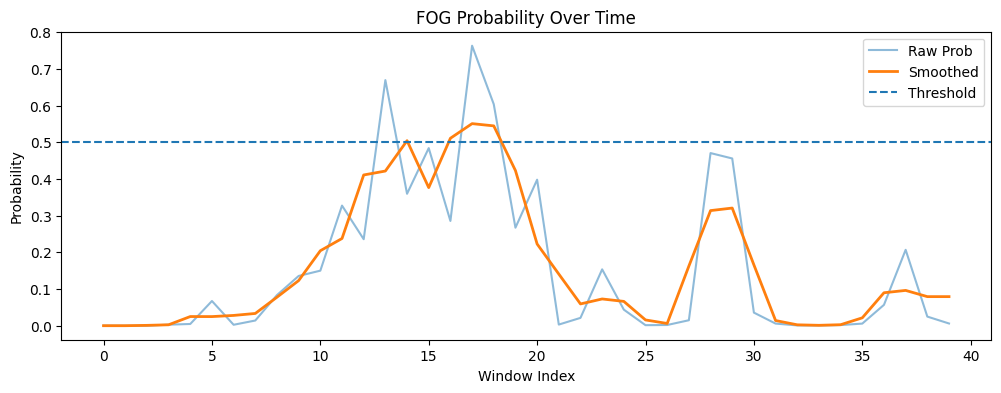

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(all_probs, label="Raw Prob", alpha=0.5)
plt.plot(smoothed, label="Smoothed", linewidth=2)

plt.axhline(0.5, linestyle='--', label="Threshold")

plt.legend()
plt.title("FOG Probability Over Time")
plt.xlabel("Window Index")
plt.ylabel("Probability")

plt.show()

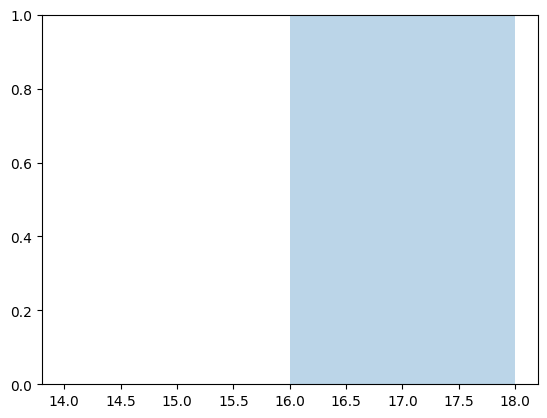

In [17]:
for (s,e) in episodes:
    start_idx = np.searchsorted(t_start, s)
    end_idx   = np.searchsorted(t_end, e)

    plt.axvspan(start_idx, end_idx, alpha=0.3)

In [18]:
fs =128

In [19]:
df["Time_actual"] = np.arange(len(df)) / fs

In [20]:
def classify_episode(df, start, end):
    ep = df[
        (df["Time_actual"] >= start) &
        (df["Time_actual"] <= end)
    ]

    sh = ep["StartHesitation"].sum()
    tu = ep["Turn"].sum()
    wa = ep["Walking"].sum()

    counts = [sh, tu, wa]
    labels = ["StartHesitation", "Turn", "Walking"]

    return labels[np.argmax(counts)]

In [21]:
results = []

for i, (start, end) in enumerate(episodes, 1):
    label = classify_episode(df, start, end)

    results.append({
        "episode": i,
        "start": start,
        "end": end,
        "label": label
    })

results_df = pd.DataFrame(results)
print(results_df)

   episode  start   end            label
0        1   14.0  15.5  StartHesitation
1        2   16.0  19.5  StartHesitation


In [22]:
df[["StartHesitation", "Turn", "Walking"]].sum()

,0
StartHesitation,0
Turn,281
Walking,0


In [23]:
episode_rows = []

for i, (s, e) in enumerate(episodes):

    episode_rows.append({
        "episode_id": i + 1,
        "start_time": s,
        "end_time": e,
        "duration": e - s
    })

episodes_df = pd.DataFrame(episode_rows)

print(episodes_df)

   episode_id  start_time  end_time  duration
0           1        14.0      15.5       1.5
1           2        16.0      19.5       3.5


# Stage 2 ML

In [2]:
import os

In [3]:
import zipfile

zip_path    = "tdcsfog.zip"
extract_path = "tdcsfog_csvs"

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_path)

csv_files = [
    os.path.join(extract_path, f)
    for f in os.listdir(extract_path)
    if f.endswith(".csv")
]

print(f"Total CSV files: {len(csv_files)}")

Total CSV files: 833


In [13]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import joblib

# ── Config ────────────────────────────────────────────────────────
DATA_DIR         = "tdcsfog_csvs"
FS               = 128
WINDOW_SIZE      = 192
SAFETY_GAP       = 64
FOG_CLEAN_THRESH = 0.2

AXES          = ["AccV", "AccML", "AccAP"]
TRIGGER_COLS  = ["StartHesitation", "Turn", "Walking"]
TRIGGER_TYPES = ["StartHesitation", "Turn", "Walking"]
FREQS         = np.fft.rfftfreq(WINDOW_SIZE, d=1/FS)

# Autocorrelation lags — chosen to capture step periodicity
# Walking cadence ~1-2 steps/s → period ~0.5-1.0s → lag 64-128 samples
AC_LAGS = [32, 48, 64, 80, 96]   # 0.25, 0.375, 0.5, 0.625, 0.75 seconds

COLORS = {
    "StartHesitation": "#e63946",
    "Turn":            "#457b9d",
    "Walking":         "#2a9d8f"
}

print("Config ready.")
print(f"Autocorrelation lags: {[l/FS for l in AC_LAGS]} seconds")

Config ready.
Autocorrelation lags: [0.25, 0.375, 0.5, 0.625, 0.75] seconds


In [14]:
def find_episodes(df):
    fog = (
        (df["StartHesitation"] == 1) |
        (df["Turn"]            == 1) |
        (df["Walking"]         == 1)
    ).astype(int).values

    sh = df["StartHesitation"].values
    tu = df["Turn"].values
    wa = df["Walking"].values

    episodes = []
    in_fog   = False
    ep_start = 0

    for i in range(len(fog)):
        if fog[i] == 1 and not in_fog:
            ep_start = i
            in_fog   = True
        elif fog[i] == 0 and in_fog:
            ep_end = i
            sh_c = sh[ep_start:ep_end].sum()
            tu_c = tu[ep_start:ep_end].sum()
            wa_c = wa[ep_start:ep_end].sum()
            trig = TRIGGER_TYPES[np.argmax([sh_c, tu_c, wa_c])]
            episodes.append((ep_start, ep_end, trig))
            in_fog = False

    if in_fog:
        ep_end = len(fog)
        sh_c = sh[ep_start:ep_end].sum()
        tu_c = tu[ep_start:ep_end].sum()
        wa_c = wa[ep_start:ep_end].sum()
        trig = TRIGGER_TYPES[np.argmax([sh_c, tu_c, wa_c])]
        episodes.append((ep_start, ep_end, trig))

    return episodes

In [15]:
def compute_features(win, trigger):
    """
    win     : (192, 3) float32
    trigger : str

    Features:
      Original 7  — var_AccAP, dom_freq_AccV, dom_freq_AccAP,
                    corr_AccV_AccAP, mean_abs_jerk_AccV,
                    mean_abs_jerk_AccML, energy_AccAP
      New         — autocorr_{axis}_lag{N} for AccV and AccML
                    at lags [32,48,64,80,96] samples
    """
    rec = {"trigger": trigger}

    for ax_idx, ax_name in enumerate(AXES):
        sig  = win[:, ax_idx]
        jerk = np.diff(sig)
        sig_detrended = sig - sig.mean()
        fft_mag = np.abs(np.fft.rfft(sig_detrended))

        # Original features
        rec[f"energy_{ax_name}"]        = float(np.mean(sig ** 2))
        rec[f"var_{ax_name}"]           = float(np.var(sig))
        rec[f"mean_abs_jerk_{ax_name}"] = float(np.mean(np.abs(jerk)))
        rec[f"dom_freq_{ax_name}"]      = float(FREQS[np.argmax(fft_mag)])

        # Autocorrelation at step-relevant lags
        # Only meaningful on AccV and AccML — vertical and lateral
        # sway are the axes that show gait rhythm
        if ax_name in ["AccV", "AccML"]:
            for lag in AC_LAGS:
                if lag < len(sig):
                    ac = np.corrcoef(
                        sig_detrended[:-lag],
                        sig_detrended[lag:]
                    )[0, 1]
                    rec[f"autocorr_{ax_name}_lag{lag}"] = float(ac)
                else:
                    rec[f"autocorr_{ax_name}_lag{lag}"] = 0.0

    # Cross-axis correlations
    rec["corr_AccV_AccML"]  = float(np.corrcoef(win[:,0], win[:,1])[0,1])
    rec["corr_AccV_AccAP"]  = float(np.corrcoef(win[:,0], win[:,2])[0,1])
    rec["corr_AccML_AccAP"] = float(np.corrcoef(win[:,1], win[:,2])[0,1])

    return rec


print("Functions defined.")

Functions defined.


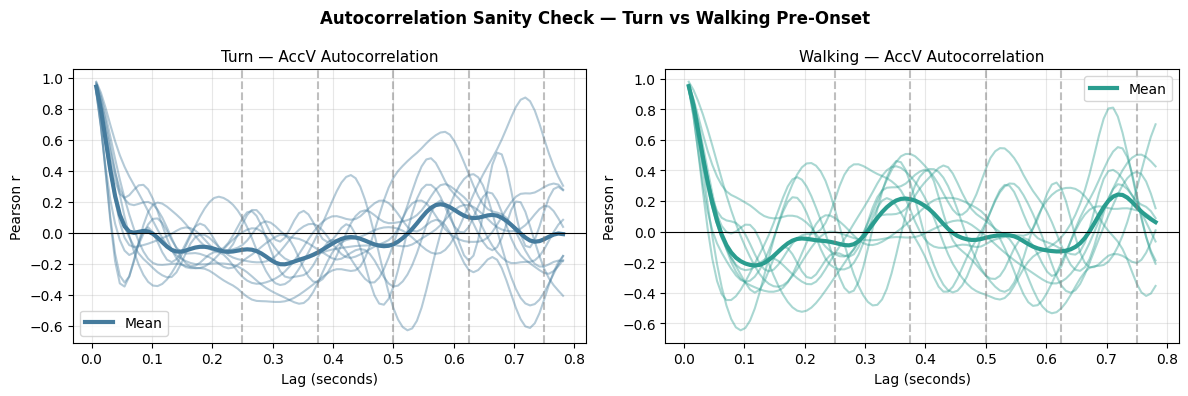

If Walking shows oscillating AC and Turn shows flat/decaying AC — features will help.


In [16]:
csv_files = [
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if f.endswith(".csv")
]
required = set(AXES + TRIGGER_COLS)

# Collect a few pre-onset windows per class for visual check
sanity = {"Turn": [], "Walking": []}
target_n = 10  # just 10 per class is enough to see the pattern

for path in csv_files:
    if all(len(v) >= target_n for v in sanity.values()):
        break

    df = pd.read_csv(path)
    if not required.issubset(df.columns):
        continue

    signals = df[AXES].values.astype(np.float32)
    fog_arr = (
        (df["StartHesitation"].values == 1) |
        (df["Turn"].values == 1) |
        (df["Walking"].values == 1)
    ).astype(np.float32)

    for (ep_start, ep_end, trig) in find_episodes(df):
        if trig not in sanity or len(sanity[trig]) >= target_n:
            continue
        pre_end   = ep_start - SAFETY_GAP
        pre_start = pre_end  - WINDOW_SIZE
        if pre_start < 0:
            continue
        if fog_arr[pre_start:pre_end].mean() > FOG_CLEAN_THRESH:
            continue
        sanity[trig].append(signals[pre_start:pre_end, 0])  # AccV only

    del signals, fog_arr

# Plot autocorrelation function for Turn vs Walking
max_lag = 100
lags    = np.arange(1, max_lag + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for col, (trig, color) in enumerate([("Turn", "#457b9d"), ("Walking", "#2a9d8f")]):
    ax = axes[col]
    for win in sanity[trig]:
        sig = win - win.mean()
        ac  = [np.corrcoef(sig[:-l], sig[l:])[0,1] for l in lags]
        ax.plot(lags/FS, ac, alpha=0.4, color=color)

    # Mean autocorrelation
    all_ac = []
    for win in sanity[trig]:
        sig = win - win.mean()
        all_ac.append([np.corrcoef(sig[:-l], sig[l:])[0,1] for l in lags])
    mean_ac = np.mean(all_ac, axis=0)
    ax.plot(lags/FS, mean_ac, color=color, linewidth=3, label="Mean")

    # Mark our chosen lags
    for lag in AC_LAGS:
        ax.axvline(lag/FS, linestyle='--', color='gray', alpha=0.5)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f"{trig} — AccV Autocorrelation", fontsize=11)
    ax.set_xlabel("Lag (seconds)")
    ax.set_ylabel("Pearson r")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Autocorrelation Sanity Check — Turn vs Walking Pre-Onset",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("If Walking shows oscillating AC and Turn shows flat/decaying AC — features will help.")

In [17]:
records = []

for path in tqdm(csv_files, desc="Extracting features"):
    df = pd.read_csv(path)
    if not required.issubset(df.columns):
        continue

    signals = df[AXES].values.astype(np.float32)
    fog_arr = (
        (df["StartHesitation"].values == 1) |
        (df["Turn"].values            == 1) |
        (df["Walking"].values         == 1)
    ).astype(np.float32)

    for (ep_start, ep_end, trig) in find_episodes(df):
        pre_end   = ep_start - SAFETY_GAP
        pre_start = pre_end  - WINDOW_SIZE
        if pre_start < 0:
            continue
        if fog_arr[pre_start:pre_end].mean() > FOG_CLEAN_THRESH:
            continue

        win = signals[pre_start:pre_end]
        rec = compute_features(win, trig)
        records.append(rec)
        del win

    del signals, fog_arr
    gc.collect()

feat_df = pd.DataFrame(records)

print(f"Total windows    : {len(feat_df)}")
print(f"Feature matrix   : {feat_df.shape}")
print("\nClass distribution:")
print(feat_df["trigger"].value_counts())
print("\nNew autocorrelation features:")
ac_cols = [c for c in feat_df.columns if "autocorr" in c]
print(ac_cols)

Extracting features: 100%|██████████| 833/833 [02:25<00:00,  5.73it/s]

Total windows    : 979
Feature matrix   : (979, 26)

Class distribution:
trigger
Turn               814
StartHesitation     86
Walking             79
Name: count, dtype: int64

New autocorrelation features:
['autocorr_AccV_lag32', 'autocorr_AccV_lag48', 'autocorr_AccV_lag64', 'autocorr_AccV_lag80', 'autocorr_AccV_lag96', 'autocorr_AccML_lag32', 'autocorr_AccML_lag48', 'autocorr_AccML_lag64', 'autocorr_AccML_lag80', 'autocorr_AccML_lag96']


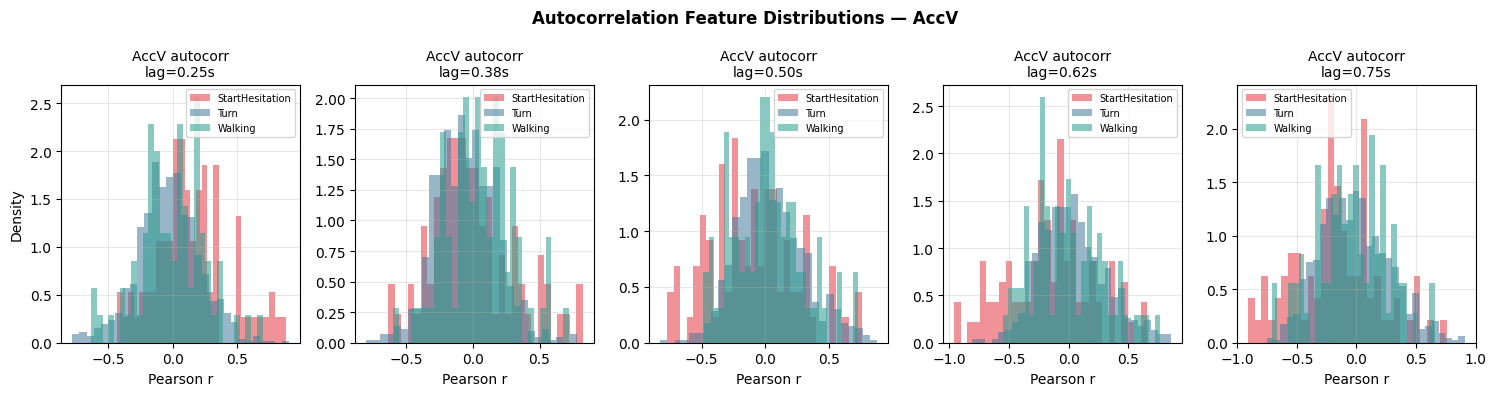

In [18]:
ac_accv_cols = [c for c in ac_cols if "AccV" in c]

fig, axes_grid = plt.subplots(1, len(ac_accv_cols), figsize=(15, 4))

for col, feat in enumerate(ac_accv_cols):
    ax = axes_grid[col]
    for trig in TRIGGER_TYPES:
        vals = feat_df[feat_df["trigger"] == trig][feat]
        ax.hist(vals, bins=30, alpha=0.55,
                color=COLORS[trig], label=trig, density=True)
    lag_s = int(feat.split("lag")[1]) / FS
    ax.set_title(f"AccV autocorr\nlag={lag_s:.2f}s", fontsize=10)
    ax.set_xlabel("Pearson r")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel("Density")

plt.suptitle("Autocorrelation Feature Distributions — AccV",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
ORIGINAL_FEATURES = [
    "var_AccAP",
    "dom_freq_AccV",
    "dom_freq_AccAP",
    "corr_AccV_AccAP",
    "mean_abs_jerk_AccV",
    "mean_abs_jerk_AccML",
    "energy_AccAP",
]

ALL_FEATURES = ORIGINAL_FEATURES + ac_cols

X = feat_df[ALL_FEATURES].values
y = feat_df["trigger"].values

le = LabelEncoder()
le.fit(TRIGGER_TYPES)
y_enc = le.transform(y)

print(f"Total features   : {len(ALL_FEATURES)}")
print(f"  Original       : {len(ORIGINAL_FEATURES)}")
print(f"  Autocorrelation: {len(ac_cols)}")
print(f"X shape          : {X.shape}")

Total features   : 17
  Original       : 7
  Autocorrelation: 10
X shape          : (979, 17)


In [20]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_true = []
all_pred = []
fold_per_class = {t: [] for t in le.classes_}
fold_macro     = []

print("Running stratified 5-fold CV...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_enc), 1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_enc[train_idx], y_enc[val_idx]

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)

    macro_f1     = f1_score(y_val, y_pred, average="macro",  zero_division=0)
    per_class_f1 = f1_score(y_val, y_pred, average=None,
                             labels=[0,1,2], zero_division=0)

    fold_macro.append(macro_f1)
    for i, t in enumerate(le.classes_):
        fold_per_class[t].append(per_class_f1[i])

    all_true.extend(y_val)
    all_pred.extend(y_pred)

    print(f"Fold {fold} | Macro F1: {macro_f1:.3f} | "
          f"SH: {per_class_f1[0]:.3f}  "
          f"Turn: {per_class_f1[1]:.3f}  "
          f"Walk: {per_class_f1[2]:.3f}")

print(f"\nMean Macro F1 : {np.mean(fold_macro):.3f}  "
      f"(±{np.std(fold_macro):.3f})")

Running stratified 5-fold CV...

Fold 1 | Macro F1: 0.506 | SH: 0.588  Turn: 0.930  Walk: 0.000
Fold 2 | Macro F1: 0.394 | SH: 0.273  Turn: 0.909  Walk: 0.000
Fold 3 | Macro F1: 0.553 | SH: 0.727  Turn: 0.933  Walk: 0.000
Fold 4 | Macro F1: 0.526 | SH: 0.643  Turn: 0.934  Walk: 0.000
Fold 5 | Macro F1: 0.522 | SH: 0.645  Turn: 0.921  Walk: 0.000

Mean Macro F1 : 0.500  (±0.055)


AGGREGATED CLASSIFICATION REPORT (all folds)
                 precision    recall  f1-score   support

StartHesitation       0.71      0.51      0.59        86
           Turn       0.87      0.98      0.93       814
        Walking       0.00      0.00      0.00        79

       accuracy                           0.86       979
      macro avg       0.53      0.50      0.51       979
   weighted avg       0.79      0.86      0.82       979



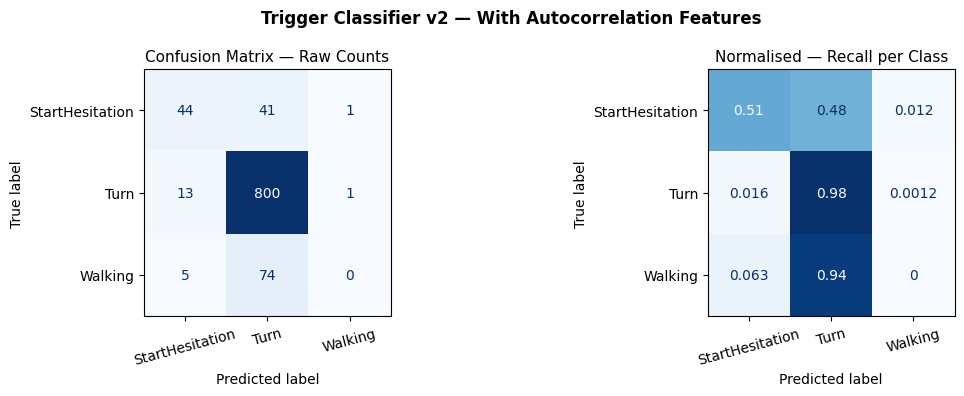

In [21]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)

print("=" * 55)
print("AGGREGATED CLASSIFICATION REPORT (all folds)")
print("=" * 55)
print(classification_report(
    all_true, all_pred,
    target_names=le.classes_,
    zero_division=0
))

cm      = confusion_matrix(all_true, all_pred, labels=[0,1,2])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Raw Counts", fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Normalised — Recall per Class", fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Trigger Classifier v2 — With Autocorrelation Features",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

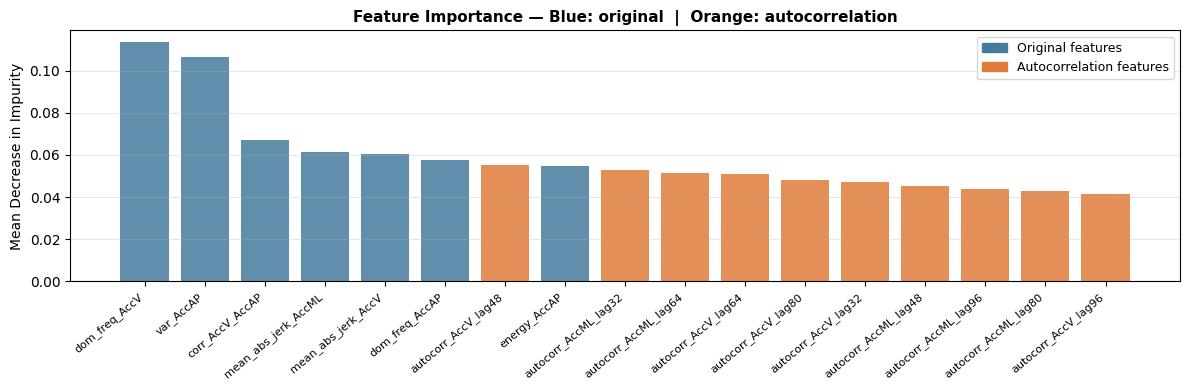


Top 10 features:
  [OR] dom_freq_AccV                       0.1134
  [OR] var_AccAP                           0.1065
  [OR] corr_AccV_AccAP                     0.0671
  [OR] mean_abs_jerk_AccML                 0.0612
  [OR] mean_abs_jerk_AccV                  0.0603
  [OR] dom_freq_AccAP                      0.0575
  [AC] autocorr_AccV_lag48                 0.0551
  [OR] energy_AccAP                        0.0548
  [AC] autocorr_AccML_lag32                0.0529
  [AC] autocorr_AccML_lag64                0.0513


In [22]:
clf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
clf_full.fit(X, y_enc)

importances = clf_full.feature_importances_
order       = np.argsort(importances)[::-1]

# Color bars by feature type
bar_colors = [
    "#e07b39" if "autocorr" in ALL_FEATURES[i] else "#457b9d"
    for i in order
]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(ALL_FEATURES)), importances[order], color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(ALL_FEATURES)))
ax.set_xticklabels([ALL_FEATURES[i] for i in order],
                    rotation=40, ha='right', fontsize=8)
ax.set_ylabel("Mean Decrease in Impurity")
ax.set_title("Feature Importance — Blue: original  |  Orange: autocorrelation",
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#457b9d", label="Original features"),
    Patch(color="#e07b39", label="Autocorrelation features")
], fontsize=9)

plt.tight_layout()
plt.savefig("trigger_v2_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
for i in order[:10]:
    ftype = "[AC]" if "autocorr" in ALL_FEATURES[i] else "[OR]"
    print(f"  {ftype} {ALL_FEATURES[i]:<35} {importances[i]:.4f}")

# Stage 2 DL

In [30]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)

# ── Config ────────────────────────────────────────────────────────
DATA_DIR         = "tdcsfog_csvs"
FS               = 128
WINDOW_SIZE      = 192
SAFETY_GAP       = 64
FOG_CLEAN_THRESH = 0.2

AXES          = ["AccV", "AccML", "AccAP"]
TRIGGER_COLS  = ["StartHesitation", "Turn", "Walking"]
TRIGGER_TYPES = ["StartHesitation", "Turn", "Walking"]

BATCH_SIZE = 32       # smaller than Stage 1 — dataset is much smaller
EPOCHS     = 50
LR         = 1e-3
TEST_SIZE  = 0.20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Window : {WINDOW_SIZE/FS:.2f}s | Safety gap: {SAFETY_GAP/FS:.2f}s")

Device: cpu
Window : 1.50s | Safety gap: 0.50s


In [20]:
def find_episodes(df):
    fog = (
        (df["StartHesitation"] == 1) |
        (df["Turn"]            == 1) |
        (df["Walking"]         == 1)
    ).astype(int).values

    sh = df["StartHesitation"].values
    tu = df["Turn"].values
    wa = df["Walking"].values

    episodes = []
    in_fog   = False
    ep_start = 0

    for i in range(len(fog)):
        if fog[i] == 1 and not in_fog:
            ep_start = i
            in_fog   = True
        elif fog[i] == 0 and in_fog:
            ep_end = i
            sh_c = sh[ep_start:ep_end].sum()
            tu_c = tu[ep_start:ep_end].sum()
            wa_c = wa[ep_start:ep_end].sum()
            trig = TRIGGER_TYPES[np.argmax([sh_c, tu_c, wa_c])]
            episodes.append((ep_start, ep_end, trig))
            in_fog = False

    if in_fog:
        ep_end = len(fog)
        sh_c = sh[ep_start:ep_end].sum()
        tu_c = tu[ep_start:ep_end].sum()
        wa_c = wa[ep_start:ep_end].sum()
        trig = TRIGGER_TYPES[np.argmax([sh_c, tu_c, wa_c])]
        episodes.append((ep_start, ep_end, trig))

    return episodes


csv_files = [
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if f.endswith(".csv")
]
required = set(AXES + TRIGGER_COLS)

windows_list  = []
triggers_list = []

for path in tqdm(csv_files, desc="Extracting windows"):
    df = pd.read_csv(path)
    if not required.issubset(df.columns):
        continue

    signals = df[AXES].values.astype(np.float32)
    fog_arr = (
        (df["StartHesitation"].values == 1) |
        (df["Turn"].values            == 1) |
        (df["Walking"].values         == 1)
    ).astype(np.float32)

    for (ep_start, ep_end, trig) in find_episodes(df):
        pre_end   = ep_start - SAFETY_GAP
        pre_start = pre_end  - WINDOW_SIZE
        if pre_start < 0:
            continue
        if fog_arr[pre_start:pre_end].mean() > FOG_CLEAN_THRESH:
            continue
        windows_list.append(signals[pre_start:pre_end])  # (192, 3)
        triggers_list.append(trig)

    del signals, fog_arr
    gc.collect()

X_all = np.array(windows_list,  dtype=np.float32)  # (N, 192, 3)
y_raw = np.array(triggers_list)                     # (N,) strings

# Encode labels
le    = LabelEncoder()
le.fit(TRIGGER_TYPES)   # fixed order: SH=0, Turn=1, Walking=2
y_all = le.transform(y_raw).astype(np.int64)

print(f"\nTotal windows  : {len(X_all)}")
print(f"X shape        : {X_all.shape}")
print("Class distribution:")
for i, t in enumerate(le.classes_):
    print(f"  {t:<20} {(y_all==i).sum()}")

Extracting windows: 100%|██████████| 833/833 [03:17<00:00,  4.21it/s]


Total windows  : 979
X shape        : (979, 192, 3)
Class distribution:
  StartHesitation      86
  Turn                 814
  Walking              79


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    stratify=y_all,       # preserves class ratio in both splits
    random_state=42
)

print(f"Train : {len(X_train)}  |  Test : {len(X_test)}")
print("\nTrain class distribution:")
for i, t in enumerate(le.classes_):
    print(f"  {t:<20} {(y_train==i).sum()}")
print("\nTest class distribution:")
for i, t in enumerate(le.classes_):
    print(f"  {t:<20} {(y_test==i).sum()}")

Train : 783  |  Test : 196

Train class distribution:
  StartHesitation      69
  Turn                 651
  Walking              63

Test class distribution:
  StartHesitation      17
  Turn                 163
  Walking              16


In [32]:
class TriggerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, 192, 3)
        self.y = torch.tensor(y, dtype=torch.long)       # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]                          # (192, 3)
        # Per-channel z-score — same as Stage 1
        mean = x.mean(dim=0, keepdim=True)
        std  = x.std(dim=0,  keepdim=True) + 1e-8
        x    = (x - mean) / std
        return x, self.y[idx]


train_loader = DataLoader(
    TriggerDataset(X_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
test_loader = DataLoader(
    TriggerDataset(X_test, y_test),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 25
Test  batches : 7


In [33]:
class TriggerModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.relu  = nn.ReLU()
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(0.3)

        self.lstm = nn.LSTM(
            input_size=64, hidden_size=64,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3
        )
        # 3 outputs instead of 1
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (B, 192, 3)
        x = x.permute(0, 2, 1)              # → (B, 3, 192)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)                    # → (B, 32, 96)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)                    # → (B, 64, 48)
        x = self.drop(x)

        x = x.permute(0, 2, 1)             # → (B, 48, 64)
        x, _ = self.lstm(x)                 # → (B, 48, 128)
        x = x.mean(dim=1)                   # → (B, 128)

        return self.fc(x)                   # → (B, 3)  raw logits


model = TriggerModel(num_classes=3).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

TriggerModel(
  (conv1): Conv1d(3, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

Trainable parameters: 177,283


In [34]:
# Class weights — inversely proportional to frequency in training set
class_counts = np.bincount(y_train)   # [n_SH, n_Turn, n_Walk]
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts in train:")
for i, t in enumerate(le.classes_):
    print(f"  {t:<20} count={class_counts[i]}  weight={class_weights[i]:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=7, min_lr=1e-5
)



print(f"\nLoss     : CrossEntropyLoss (weighted)")
print(f"Optimizer: Adam  lr={LR}")

Class counts in train:
  StartHesitation      count=69  weight=1.3629
  Turn                 count=651  weight=0.1445
  Walking              count=63  weight=1.4927

Loss     : CrossEntropyLoss (weighted)
Optimizer: Adam  lr=0.001


In [35]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.002, verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.best_state = None
        self.stop       = False

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
            self.counter = 0
            if self.verbose:
                print(f"  ✓ New best: {score:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  · No improvement ({self.counter}/{self.patience})"
                      f"  best={self.best_score:.4f}")
            if self.counter >= self.patience:
                self.stop = True

early_stopper = EarlyStopping(patience=20, min_delta=0.002)

In [36]:
best_macro_f1 = 0.0
history = {"train_loss": [], "val_macro_f1": [],
           "val_f1_SH": [], "val_f1_Turn": [], "val_f1_Walk": []}

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Evaluate ───────────────────────────────────────────────────
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(device))
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    per_class = f1_score(all_labels, all_preds, average=None,
                         labels=[0, 1, 2], zero_division=0)
    macro_f1  = f1_score(all_labels, all_preds, average="macro",
                         zero_division=0)

    scheduler.step(macro_f1)

    history["train_loss"].append(train_loss)
    history["val_macro_f1"].append(macro_f1)
    history["val_f1_SH"].append(per_class[0])
    history["val_f1_Turn"].append(per_class[1])
    history["val_f1_Walk"].append(per_class[2])

    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {train_loss:.4f} | "
          f"Macro F1: {macro_f1:.3f} | "
          f"SH: {per_class[0]:.3f}  Turn: {per_class[1]:.3f}  Walk: {per_class[2]:.3f}")

    early_stopper.step(macro_f1, model)
    if early_stopper.stop:
        print(f"\nEarly stopping at epoch {epoch}. "
              f"Best Macro F1: {early_stopper.best_score:.4f}")
        break


Epoch 01/50 | Loss: 1.0785 | Macro F1: 0.473 | SH: 0.500  Turn: 0.918  Walk: 0.000
  ✓ New best: 0.4725
Epoch 02/50 | Loss: 0.9579 | Macro F1: 0.453 | SH: 0.444  Turn: 0.914  Walk: 0.000
  · No improvement (1/20)  best=0.4725
Epoch 03/50 | Loss: 0.9202 | Macro F1: 0.441 | SH: 0.387  Turn: 0.844  Walk: 0.091
  · No improvement (2/20)  best=0.4725
Epoch 04/50 | Loss: 0.8140 | Macro F1: 0.488 | SH: 0.455  Turn: 0.909  Walk: 0.100
  ✓ New best: 0.4877
Epoch 05/50 | Loss: 0.7732 | Macro F1: 0.433 | SH: 0.490  Turn: 0.621  Walk: 0.189
  · No improvement (1/20)  best=0.4877
Epoch 06/50 | Loss: 0.7620 | Macro F1: 0.559 | SH: 0.490  Turn: 0.875  Walk: 0.312
  ✓ New best: 0.5590
Epoch 07/50 | Loss: 0.7305 | Macro F1: 0.444 | SH: 0.426  Turn: 0.700  Walk: 0.206
  · No improvement (1/20)  best=0.5590
Epoch 08/50 | Loss: 0.6955 | Macro F1: 0.559 | SH: 0.514  Turn: 0.876  Walk: 0.286
  · No improvement (2/20)  best=0.5590
Epoch 09/50 | Loss: 0.7051 | Macro F1: 0.294 | SH: 0.438  Turn: 0.283  Walk: 0

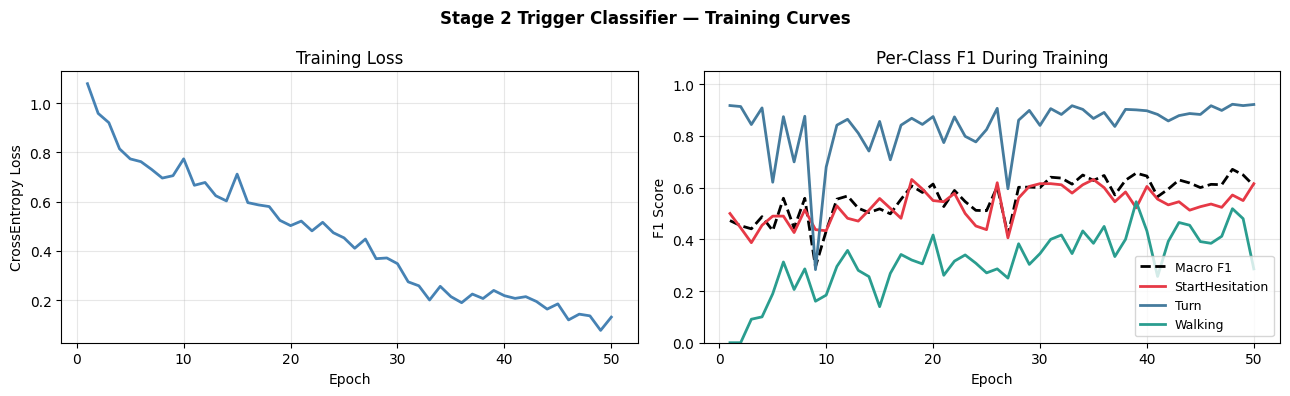

In [37]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, history["train_loss"],
             color="steelblue", linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["val_macro_f1"],
             color="black", linewidth=2, linestyle='--', label="Macro F1")
axes[1].plot(epochs_range, history["val_f1_SH"],
             color="#e63946", linewidth=2, label="StartHesitation")
axes[1].plot(epochs_range, history["val_f1_Turn"],
             color="#457b9d", linewidth=2, label="Turn")
axes[1].plot(epochs_range, history["val_f1_Walk"],
             color="#2a9d8f", linewidth=2, label="Walking")
axes[1].set_title("Per-Class F1 During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Stage 2 Trigger Classifier — Training Curves",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
best_state = early_stopper.best_state
best_macro_f1 = early_stopper.best_score

In [45]:
# Restore best weights
model.load_state_dict(best_state)
model.to(device)
print(f"\nBest Macro F1: {best_macro_f1:.4f}")

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1).cpu().numpy()
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("=" * 55)
print("FINAL TEST SET RESULTS — Best Model")
print("=" * 55)
print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    zero_division=0
))
print(f"Macro F1: {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
print("\nNOTE: Accuracy not primary metric — 83% Turn dominance.")


Best Macro F1: 0.6708
FINAL TEST SET RESULTS — Best Model
                 precision    recall  f1-score   support

StartHesitation       0.48      0.71      0.57        17
           Turn       0.93      0.91      0.92       163
        Walking       0.64      0.44      0.52        16

       accuracy                           0.86       196
      macro avg       0.68      0.69      0.67       196
   weighted avg       0.87      0.86      0.86       196

Macro F1: 0.6708

NOTE: Accuracy not primary metric — 83% Turn dominance.


In [46]:
print("\nPer-class accuracy (TP+TN / total):")
for i, name in enumerate(le.classes_):
    tp = ((all_preds == i) & (all_labels == i)).sum()
    tn = ((all_preds != i) & (all_labels != i)).sum()
    total = len(all_labels)
    print(f"  {name:<20} {(tp+tn)/total*100:.1f}%")


Per-class accuracy (TP+TN / total):
  StartHesitation      90.8%
  Turn                 87.2%
  Walking              93.4%


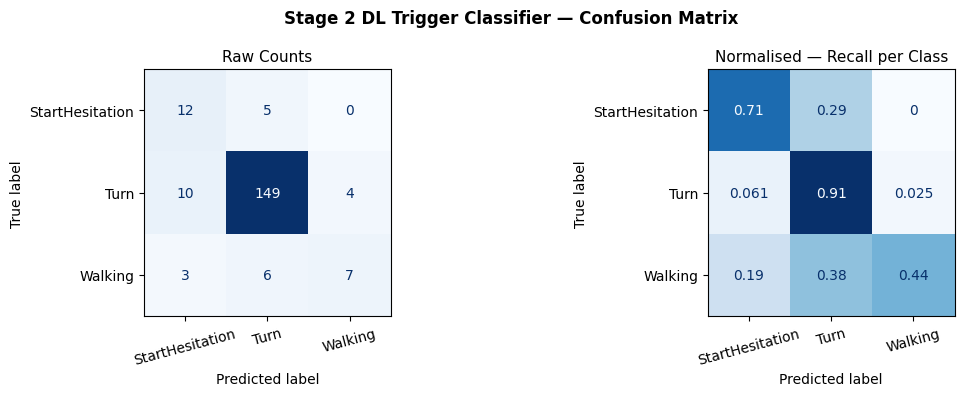

In [47]:
cm      = confusion_matrix(all_labels, all_preds, labels=[0,1,2])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Raw Counts", fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Normalised — Recall per Class", fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Stage 2 DL Trigger Classifier — Confusion Matrix",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
best_state = early_stopper.best_state
best_macro_f1 = early_stopper.best_score

In [48]:
torch.save(best_state, "trigger_dl_model.pth")
print("Saved: trigger_dl_model.pth")

# To reload:
# model = TriggerModel(num_classes=3)
# model.load_state_dict(torch.load("trigger_dl_model.pth"))
# model.eval()

import joblib
joblib.dump(le, "trigger_label_encoder.pkl")
print("Saved: trigger_label_encoder.pkl")

print(f"\nBest Macro F1 : {best_macro_f1:.4f}")
print("Per-class F1 at best epoch:")
best_epoch = np.argmax(history['val_macro_f1'])
print(f"  StartHesitation : {history['val_f1_SH'][best_epoch]:.4f}")
print(f"  Turn            : {history['val_f1_Turn'][best_epoch]:.4f}")
print(f"  Walking         : {history['val_f1_Walk'][best_epoch]:.4f}")
print(f"  (at epoch {best_epoch+1})")

Saved: trigger_dl_model.pth
Saved: trigger_label_encoder.pkl

Best Macro F1 : 0.6708
Per-class F1 at best epoch:
  StartHesitation : 0.5714
  Turn            : 0.9226
  Walking         : 0.5185
  (at epoch 48)
